In [1]:
from swemnics.problems import SlopedBeachProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dolfinx import fem as fe
import pickle
import os
import os
import pickle
import numpy as np
from itertools import product
import time
import pandas as pd
import seaborn as sns
from typing import Callable, Dict, List, Tuple, Any, Union

 
from fourd_var import run_assimilation, setup_data_assimilation, run_data_assimilation
from dca_utils import*
from plotting import plot_mixed_function, plot_comparison1, plot_comparison2

sns.set_palette("bright")
plt.style.use("mystyle1.mplstyle")


In [2]:
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

final_time = 7 * Time.TWENTY_FOUR_HOURS.seconds   # 7 days in seconds
window_size = Time.ONE_HOUR.seconds

dt = 600  # 30 minutes in seconds
problem_params = {
    'dt': dt,
    't': 0,
    't_final': final_time,
    'num_steps': int(np.ceil(final_time/dt)),
    'num_windows': final_time//window_size,  # divide by 4 hours in seconds = 42 windows
    'fric_law': 'linear',    #friction law either quadratic or linear
    'sol_var': 'h'             #solution variable either h or hu
}

solver_params = {"rtol": 1e-5,
          "atol": 1e-6,
          "max_it":10,
          "relaxation_parameter":1.0,
          "ksp_type": "gmres",
          "pc_type": "ilu",
          "ksp_ErrorIfNotConverged": False
          }#,"pc_factor_mat_solver_type":"mumps"}


prob, solver = create_problem_solver(problem_params, "sloped_beach", true_signal=True, verbose=True)





SWE TYPE full
Wetting drying activated 

Location of shoreline: 13800
setting initial condition
Fully conservative flux
Fully conservative flux
WD nonspherical

CF =  0.025
Adding DG boundary conditions weakly
Fully conservative flux


In [11]:
run_true = True

if run_true:
    assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
    true_solver = get_true_signal(solver,'sloped_beach', solver_params,1)
    true_signal = np.array(true_solver.saved_states)

    with open(os.path.join('da_output','true_signal.pkl'), 'wb') as f:
        pickle.dump(true_signal, f)

calling time loop
plot every 60
nt 1008
creating video
Interpolating bathymetry
Writing bathymetry
Wrote bathymetry
Time Step Number 0 Out of 1008
0.0 % Complete
Residual norm 5740.95006345917
linear solver convergence 2, iterations 9, resid norm 3.931858019025817e-09
dx_0 norm, 2.3121251864958534
Netwon Iteration 1: Correction norm 0.9999999999999997
Residual norm 929.9267138685886
linear solver convergence 3, iterations 8, resid norm 4.829696956884147e-10
Netwon Iteration 2: Correction norm 0.25059904550837786
Residual norm 36.55419313158538
linear solver convergence 3, iterations 7, resid norm 2.325534983029459e-10
Netwon Iteration 3: Correction norm 0.008649214703196554
Residual norm 0.019555068388491303
linear solver convergence 3, iterations 3, resid norm 7.013546528679652e-10
Netwon Iteration 4: Correction norm 3.867937239237327e-06
Residual norm 7.20948345622688e-06
linear solver convergence 3, iterations 0, resid norm 7.015337921001044e-10
Netwon Iteration 5: Correction norm 0

In [4]:
# run_true = False
# if run_true:
#     # # Plot 1: Time series at a single grid point (e.g., center point)
#     mid_idx = true_signal.shape[1] // 2
#     plt.figure(figsize=(10, 4))
#     plt.plot(true_signal[:, mid_idx], label=f"Grid point 1 {mid_idx}")
#     # plt.plot(true_signal2[:, mid_idx],label=f"Grid point 2 {mid_idx}")  # Add points for clarity
#     plt.xlabel("Time step")
#     plt.ylabel("Solution value")
#     plt.title("Time series at grid point")
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 2: Spatial average over time
#     spatial_mean = true_signal.mean(axis=1)
#     plt.figure(figsize=(10, 4))
#     plt.plot(spatial_mean, label="Spatial average")
#     plt.xlabel("Time step")
#     plt.ylabel("Average solution")
#     plt.title("Spatial average over time")
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 3: Time–space heatmap with time on x-axis
#     plt.figure(figsize=(12, 6))
#     plt.imshow(true_signal.T, aspect='auto', cmap='viridis', origin='lower')
#     plt.colorbar(label="Solution value")
#     plt.xlabel("Time step")
#     plt.ylabel("Spatial index")
#     plt.title("Time–space heatmap of true signal (time on x-axis)")
#     plt.tight_layout()
#     plt.show()



In [7]:

# # open true signal with pickle
# with open(os.path.join('da_output','true_signal.pkl'), 'rb') as f:
#     true_signal = pickle.load(f)

# # problem_params['fric_law'] = 'mannings'  # Change friction law to mannings for this DA experiment
# problem_params.update({'fric_law': 'mannings', 'dt': 600}) # Change friction law to mannings for this DA expirement

# obs_std=1.1
# obs_time_freq = 1
# obs_space_freq = 2 # Frequency of observation in space (every 4th cell) # Note observations are taken in terms of height, not velocity
# total_steps = int((problem_params['t_final']/problem_params['dt']) + 1)
# problem_params['num_steps'] = int(np.ceil(final_time/problem_params['dt'])/problem_params['num_windows']) # Size of each assimilation window
# obs_per_window = problem_params['num_steps'] // obs_time_freq

# H, stations, obs_spatial_indices = build_observation_matrix(prob, prob.V, obs_space_freq)
# obs_indices_per_window, obs_time_indices = setup_observation_indices(problem_params['num_steps'], obs_time_freq, total_steps)

# # Create synthetic observations
# y_obs = generate_observations(true_signal, H, obs_time_indices, obs_std)


# # Generate Background,Observation, and Predicted Error Covariance Matrices
# state_dim = true_signal.shape[1]
# obs_dim = stations.shape[0]

# # Observation Covariance 
# R = np.eye(obs_dim) * (obs_std**2)

# inflation_factor = 4.0
# B = inflation_factor*np.eye(state_dim) 

# # Predicted Covariance
# L = H @ B @ H.T 

# # Get Inverse Covariance matrices
# R_inv = np.linalg.inv(R)
# B_inv = np.linalg.inv(B) 
# L_inv = np.linalg.inv(L)

# covs = {"B_inv": B_inv, "R_inv": R_inv, "L_inv": L_inv}

# hb = 5.0 / 13800 * (13800 - stations[:, 0])

# print(f"\n Total Steps: {total_steps}\n"
#       f"Total Assimilation Windows: {problem_params['num_windows']}\n"
#       f"Steps per Window: {problem_params['num_steps']}\n"
#       f"Obs Time Frequency: {obs_time_freq}\n"
#       f"Total Obs: {obs_per_window * problem_params['num_windows']}\n"
#       f"Number Stations: {stations.shape[0]}\n"
#       f"Obs per Window: {obs_per_window}\n"
#       )




# print(f"\nState Dimension: {state_dim}\n"
#       f"Observation Dimension: {obs_dim}\n"
#       f"Background Covariance Matrix Shape B: {B.shape}\n"
#       f"Observation Covariance Matrix Shape R: {R.shape}\n"
#       f"Predicted Error Covariance Matrix shape L: {L.shape}\n"
#       f"Observation Matrix Shape H: {H.shape}\n",
#       f"y_obs shape: {y_obs.shape}\n",
#       f"Stations shape: {stations.shape}\n",
# )





In [ ]:
def run_parameter_crossval(pickle_path, problem_params, prob, solver_params, 
                       obs_space_freq, obs_time_freq, final_time,
                       obs_std_values, inflation_factor_values, 
                       output_dir='da_output', verbose=True):
    """
    Run a parameter cross validation over observation standard deviation and inflation factor values.
    
    Parameters:
    -----------
    pickle_path : str
        Path to the pickle file containing true_signal
    problem_params : dict
        Dictionary containing problem parameters
    prob : object
        Problem object with V attribute
    solver_params : dict
        Solver parameters for run_assimilation
    obs_space_freq : int
        Frequency of observation in space
    obs_time_freq : int
        Frequency of observation in time
    final_time : float
        Final time for the problem
    obs_std_values : list
        List of observation standard deviation values to test
    inflation_factor_values : list
        List of inflation factor values to test
    output_dir : str, default='da_output'
        Directory to save results
    verbose : bool, default=True
        If True, prints progress information
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Store all results
    all_results = {}
    
    # Calculate total number of experiments
    total_experiments = len(obs_std_values) * len(inflation_factor_values)
    experiment_count = 0
    
    if verbose:
        print(f"Starting parameter cross validation with {total_experiments} experiments")
        print(f"obs_std values: {obs_std_values}")
        print(f"inflation_factor values: {inflation_factor_values}")
        print("=" * 80)
    
    # Loop through all combinations
    for obs_std, inflation_factor in product(obs_std_values, inflation_factor_values):
        experiment_count += 1
        experiment_name = f"obs_std_{obs_std}_inflation_{inflation_factor}"
        
        if verbose:
            print(f"\nExperiment {experiment_count}/{total_experiments}: {experiment_name}")
            start_time = time.time()
        
        try:
            # Setup data assimilation
            result = setup_data_assimilation(
                pickle_path=pickle_path,
                problem_params=problem_params.copy(),  # Use copy to avoid modifying original
                prob=prob,
                obs_std=obs_std,
                obs_space_freq=obs_space_freq,
                obs_time_freq=obs_time_freq,
                final_time=final_time,
                inflation_factor=inflation_factor,
                print_setup=True  # Set to True if you want detailed output for each experiment
            )
            
            # Run assimilation - this might call sys.exit(1) if solver doesn't converge
            dci_wme_analysis = run_assimilation(
                result['problem_params'],
                solver_params,
                result['stations'],
                result['y_obs'],
                result['obs_per_window'],
                result['obs_time_indices'],
                result['H'],
                result['covs'],
                result['hb'],
                'sloped_beach',
                cost_function_type='dci_wme'
            )
            
            # Save individual result
            output_filename = os.path.join(output_dir, f'dci_wme_analysis_{experiment_name}.pkl')
            with open(output_filename, 'wb') as f:
                pickle.dump(dci_wme_analysis, f)
            
            # Store in summary dictionary
            all_results[experiment_name] = {
                'obs_std': obs_std,
                'inflation_factor': inflation_factor,
                'analysis': dci_wme_analysis,
                'setup_result': result,
                'output_file': output_filename
            }
            
            if verbose:
                elapsed_time = time.time() - start_time
                print(f"  ✓ Completed in {elapsed_time:.2f}s - Saved to {output_filename}")
                
        except SystemExit as e:
            # Handle the case where run_assimilation calls sys.exit(1) due to solver non-convergence
            if verbose:
                elapsed_time = time.time() - start_time
                print(f"  ✗ Solver failed to converge (sys.exit called) after {elapsed_time:.2f}s")
            all_results[experiment_name] = {
                'obs_std': obs_std,
                'inflation_factor': inflation_factor,
                'error': f'Solver convergence failure (SystemExit: {e.code})',
                'error_type': 'convergence_failure'
            }
            
        except Exception as e:
            if verbose:
                elapsed_time = time.time() - start_time
                print(f"  ✗ Failed after {elapsed_time:.2f}s: {str(e)}")
            all_results[experiment_name] = {
                'obs_std': obs_std,
                'inflation_factor': inflation_factor,
                'error': str(e),
                'error_type': 'general_exception'
            }
    
    # Save summary of all results
    summary_filename = os.path.join(output_dir, 'parameter_crossval_summary.pkl')
    with open(summary_filename, 'wb') as f:
        pickle.dump(all_results, f)
    
    if verbose:
        print("\n" + "=" * 80)
        print(f"Parameter cross validation completed!")
        print(f"Results saved to: {output_dir}")
        print(f"Summary saved to: {summary_filename}")
        
        # Print success/failure summary
        successful = sum(1 for result in all_results.values() if 'error' not in result)
        convergence_failures = sum(1 for result in all_results.values() 
                                 if result.get('error_type') == 'convergence_failure')
        other_failures = sum(1 for result in all_results.values() 
                           if 'error' in result and result.get('error_type') != 'convergence_failure')
        
        print(f"Successful experiments: {successful}/{total_experiments}")
        if convergence_failures > 0:
            print(f"Convergence failures (solver didn't converge): {convergence_failures}")
        if other_failures > 0:
            print(f"Other failures: {other_failures}")
        
        # List parameter combinations that failed due to convergence
        if convergence_failures > 0:
            print(f"\nParameter combinations with convergence failures:")
            for exp_name, result in all_results.items():
                if result.get('error_type') == 'convergence_failure':
                    print(f"  obs_std={result['obs_std']}, inflation_factor={result['inflation_factor']}")
    
    return all_results






In [ ]:
# Example usage:
if __name__ == "__main__":
    # Define parameter ranges to test
    obs_std_values = [1.1]
    inflation_factor_values = [4.0]
    # inflation_factor_values = [4.0, 5.0, 6.0, 7.0]
    
    final_time = 7 * Time.TWENTY_FOUR_HOURS.seconds   # 7 days in seconds
    window_size = Time.ONE_HOUR.seconds

    dt = 600  # 30 minutes in seconds
    problem_params = {
        'dt': dt,
        't': 0,
        't_final': final_time,
        'num_steps': int(np.ceil(final_time/dt)),
        'num_windows': final_time//window_size,  # divide by 4 hours in seconds = 42 windows
        'fric_law': 'linear',    #friction law either quadratic or linear
        'sol_var': 'h'             #solution variable either h or hu
    }

    solver_params = {"rtol": 1e-5,
            "atol": 1e-6,
            "max_it":10,
            "relaxation_parameter":1.0,
            "ksp_type": "gmres",
            "pc_type": "ilu",
            "ksp_ErrorIfNotConverged": False
            }#,"pc_factor_mat_solver_type":"mumps"}


    prob, solver = create_problem_solver(problem_params, "sloped_beach", true_signal=True, verbose=True)
    
    run_true = True

    if run_true:
        assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
        true_solver = get_true_signal(solver,'sloped_beach', solver_params,1)
        true_signal = np.array(true_solver.saved_states)

        with open(os.path.join('da_output','true_signal.pkl'), 'wb') as f:
            pickle.dump(true_signal, f)

    
    # Run the parameter sweep
    results = run_parameter_crossval(
        pickle_path=os.path.join('da_output', 'true_signal.pkl'),
        problem_params=problem_params,  # Your problem_params dict
        prob=prob,  
        solver_params=solver_params,  # Your solver_params dict
        obs_space_freq=2,  # Your obs_space_freq value
        obs_time_freq=1,  # Your obs_time_freq value
        final_time=final_time,  # Your final_time value
        obs_std_values=obs_std_values,
        inflation_factor_values=inflation_factor_values,
        output_dir='da_output',
        verbose=True
    )
    
    # Optional: Print some summary statistics
    print("\nParameter sweep results summary:")
    for exp_name, output in results.items():
        if 'error' not in output:
            print(f"{exp_name}: SUCCESS")
        elif output.get('error_type') == 'convergence_failure':
            print(f"{exp_name}: CONVERGENCE FAILURE (solver didn't converge)")
        else:
            print(f"{exp_name}: FAILED - {output['error']}")
    
    # Print recommendations for convergence failures
    convergence_failures = [output for output in results.values() 
                          if output.get('error_type') == 'convergence_failure']
    if convergence_failures:
        print(f"\nNote: {len(convergence_failures)} experiments failed due to solver convergence issues.")
        print("Consider trying:")
        print("- Different obs_std and inflation_factor combinations")
        print("- Adjusting solver parameters (tolerance, max iterations)")
        print("- Checking if the observation setup is reasonable for the problem")

Starting parameter cross validation with 1 experiments
obs_std values: [1.1]
inflation_factor values: [4.0]

Experiment 1/1: obs_std_1.1_inflation_4.0
DATA ASSIMILATION EXPERIMENT SETUP

Input Parameters:
  Pickle path: da_output/true_signal.pkl
  Observation std deviation: 1.1
  Observation space frequency: 2
  Observation time frequency: 1
  Final time: 604800
  Inflation factor: 4.0

Problem Parameters:
  dt: 600
  t: 601200
  t_final: 604800
  num_steps: 6
  num_windows: 168
  fric_law: mannings
  sol_var: h

Calculated Dimensions:
  State dimension: 1296
  Observation dimension: 72
  Total time steps: 1009
  Observations per window: 6
  Number of observation stations: 72

Matrix Information:
  Observation matrix H shape: (72, 1296)
  Background covariance B shape: (1296, 1296)
  Observation covariance R shape: (72, 72)
  Predicted covariance L shape: (72, 72)

Observation Setup:
  Number of observation time indices: 1008
  Observation spatial indices: [ 0  2  4  6  8 10 12 14 16 1

Processing windows:  42%|████▏     | 71/168 [04:20<08:37,  5.33s/window]

Optimization failed:


Optimization completed:
  Success: False
  Status: 2
  Message: ABNORMAL: 
  Final cost: 1.496361e+02
  Iterations: 4
  Function evaluations: 43
  Gradient norm at solution: 4.351439e-03

------------------------------------------------------------



Processing windows:  93%|█████████▎| 156/168 [09:39<01:04,  5.40s/window]

Optimization failed:


Optimization completed:
  Success: False
  Status: 2
  Message: ABNORMAL: 
  Final cost: 7.457003e+01
  Iterations: 4
  Function evaluations: 43
  Gradient norm at solution: 4.733861e-03

------------------------------------------------------------



Processing windows:  99%|█████████▉| 167/168 [10:22<00:04,  4.71s/window]

Optimization failed:


Optimization completed:
  Success: False
  Status: 2
  Message: ABNORMAL: 
  Final cost: 1.451096e+02
  Iterations: 4
  Function evaluations: 33
  Gradient norm at solution: 3.609694e-03

------------------------------------------------------------



Processing windows: 100%|██████████| 168/168 [10:25<00:00,  3.72s/window]

  ✓ Completed in 625.54s - Saved to da_output/dci_wme_analysis_obs_std_1.1_inflation_4.0.pkl

Parameter cross validation completed!
Results saved to: da_output
Summary saved to: da_output/parameter_crossval_summary.pkl
Successful experiments: 1/1

Parameter sweep results summary:
obs_std_1.1_inflation_4.0: SUCCESS


In [14]:
obs_std_values = [1.1]
inflation_factor_values = [4.0]
    
wme_results = analyze_error_statistics(obs_std_values, inflation_factor_values,result, 
                            analysis_type='dci_wme', output_dir='da_output')


Error Statistics for DCI_WME Analysis
Obs Std    Inflation    RMSE            Misfit         
------------------------------------------------------------
1.100000 4.000000 0.521739 206.002818
------------------------------------------------------------


In [9]:
wme_results

{(1.1, 4.0): {'rmse': np.float64(0.5217393526472367),
  'misfit': np.float64(206.00281807838465)}}

In [ ]:
print(f"max:{H.max()}, "
      f"min: {H.min()}, "
      f"2-norm: {np.linalg.norm(H, ord=2)}, "
      f"cond #: {np.linalg.cond(H)}, "
      f"rank: {np.linalg.matrix_rank(H)}")

In [17]:
result = setup_data_assimilation(
    pickle_path=os.path.join('da_output', 'true_signal.pkl'),
    problem_params=problem_params,
    prob=prob,
    obs_std=1.1,
    obs_space_freq=2,
    obs_time_freq=1,
    final_time=final_time,
    inflation_factor=4.0,
    print_setup=True
)

bayes_analysis = run_assimilation(
                                  problem_params,
                                  solver_params,
                                  result['stations'],
                                  result['y_obs'],
                                  result['obs_per_window'],
                                  result['obs_time_indices'],
                                  result['H'],
                                  result['covs'],
                                  result['hb'],
                                'sloped_beach',
                                cost_function_type='bayes'
                             )

# save bayes_analysis to a pickle file
with open(os.path.join('da_output','bayes_analysis.pkl'), 'wb') as f:
    pickle.dump(bayes_analysis, f)

# # get bayes_analysis from the pickle file
# with open(os.path.join('da_output','bayes_analysis.pkl'), 'rb') as f:
#     bayes_analysis = pickle.load(f)

true_obs_bayes = result['H'] @ true_signal[result['obs_time_indices']].T
pred_obs_bayes = result['H'] @ bayes_analysis[result['obs_time_indices']].T
bayes_rmse = np.sqrt(np.mean((true_signal - bayes_analysis) ** 2)) # time averaged RMSE
bayes_misfit = np.linalg.norm(true_obs_bayes - pred_obs_bayes, ord=2)        # time averaged misfit
print(f"4DVar RMSE: {bayes_rmse:<.10f}, 4DVar Misfit: {bayes_misfit:<.4f}")


DATA ASSIMILATION EXPERIMENT SETUP

Input Parameters:
  Pickle path: da_output/true_signal.pkl
  Observation std deviation: 1.1
  Observation space frequency: 2
  Observation time frequency: 1
  Final time: 604800
  Inflation factor: 4.0

Problem Parameters:
  dt: 600
  t: 0
  t_final: 604800
  num_steps: 6
  num_windows: 168
  fric_law: mannings
  sol_var: h

Calculated Dimensions:
  State dimension: 1296
  Observation dimension: 72
  Total time steps: 1009
  Observations per window: 6
  Number of observation stations: 72

Matrix Information:
  Observation matrix H shape: (72, 1296)
  Background covariance B shape: (1296, 1296)
  Observation covariance R shape: (72, 72)
  Predicted covariance L shape: (72, 72)

Observation Setup:
  Number of observation time indices: 1008
  Observation spatial indices: [ 0  2  4  6  8 10 12 14 16 18]...
  Station locations (first 5): [[13416.66666667   400.             0.        ]
 [12266.66666667   400.             0.        ]
 [11883.33333333   800.

Processing windows:   5%|▌         | 9/168 [00:16<09:58,  3.77s/window]

Optimization failed:


Optimization completed:
  Success: False
  Status: 2
  Message: ABNORMAL: 
  Final cost: 2.870769e+02
  Iterations: 2
  Function evaluations: 44
  Gradient norm at solution: 2.558296e-05

------------------------------------------------------------



Processing windows: 100%|██████████| 168/168 [04:15<00:00,  1.52s/window]

4DVar RMSE: 0.5413179374, 4DVar Misfit: 215.6342


In [ ]:
result = setup_data_assimilation(
    pickle_path=os.path.join('da_output', 'true_signal.pkl'),
    problem_params=problem_params,
    prob=prob,
    obs_std=1.1,
    obs_space_freq=2,
    obs_time_freq=1,
    final_time=final_time,
    inflation_factor=4.0,
    print_setup=True
)

dci_analysis = run_assimilation(
                                  problem_params,
                                  solver_params,
                                  result['stations'],
                                  result['y_obs'],
                                  result['obs_per_window'],
                                  result['obs_time_indices'],
                                  result['H'],
                                  result['covs'],
                                  result['hb'],
                                'sloped_beach',
                                cost_function_type='dci'
                             )

# save wme_analysis to a pickle file
with open(os.path.join('da_output','dci_analysis.pkl'), 'wb') as f:
    pickle.dump(dci_analysis, f)

# get dci_analysis from the pickle file
# with open(os.path.join('da_output','dci_analysis.pkl'), 'rb') as f:
#     dci_analysis = pickle.load(f)
    
true_obs_wme = result['H'] @ true_signal[result['obs_time_indices']].T
pred_obs_wme = result['H'] @ dci_analysis[result['obs_time_indices']].T
dci_rmse = np.sqrt(np.mean((true_signal - dci_analysis) ** 2)) # time averaged RMSE
dci_misfit = np.linalg.norm(true_obs_wme - pred_obs_wme, ord=2)        # time averaged misfit
print(f"DCI RMSE: {dci_rmse:<.10f}, DCI Misfit: {dci_misfit:<.4f}")

In [ ]:
result = setup_data_assimilation(
    pickle_path=os.path.join('da_output', 'true_signal.pkl'),
    problem_params=problem_params,
    prob=prob,
    obs_std=1.1,
    obs_space_freq=2,
    obs_time_freq=1,
    final_time=final_time,
    inflation_factor=4.0,
    print_setup=True
)

dci_wme_analysis = run_assimilation(
                                  problem_params,
                                  solver_params,
                                  result['stations'],
                                  result['y_obs'],
                                  result['obs_per_window'],
                                  result['obs_time_indices'],
                                  result['H'],
                                  result['covs'],
                                  result['hb'],
                                'sloped_beach',
                                cost_function_type='dci_wme'
                             )

# save wme_analysis to a pickle file
with open(os.path.join('da_output','dci_wme_analysis.pkl'), 'wb') as f:
    pickle.dump(dci_wme_analysis, f)
    
# get dci_wme_analysis from the pickle file
# with open(os.path.join('da_output','dci_wme_analysis.pkl'), 'rb') as f:
#     dci_wme_analysis = pickle.load(f)
    
true_obs_wme = result['H'] @ true_signal[result['obs_time_indices']].T
pred_obs_wme = result['H'] @ dci_wme_analysis[result['obs_time_indices']].T
wme_rmse = np.sqrt(np.mean(true_signal - dci_wme_analysis) ** 2) # time averaged RMSE
wme_misfit = np.linalg.norm(true_obs_wme - pred_obs_wme, ord=2)        # time averaged misfit
print(f"DCI WME RMSE: {wme_rmse:<.10f}, DCI WME Misfit: {wme_misfit:<.4f}")

Plot saved to: true_sloped_beach_plot.png


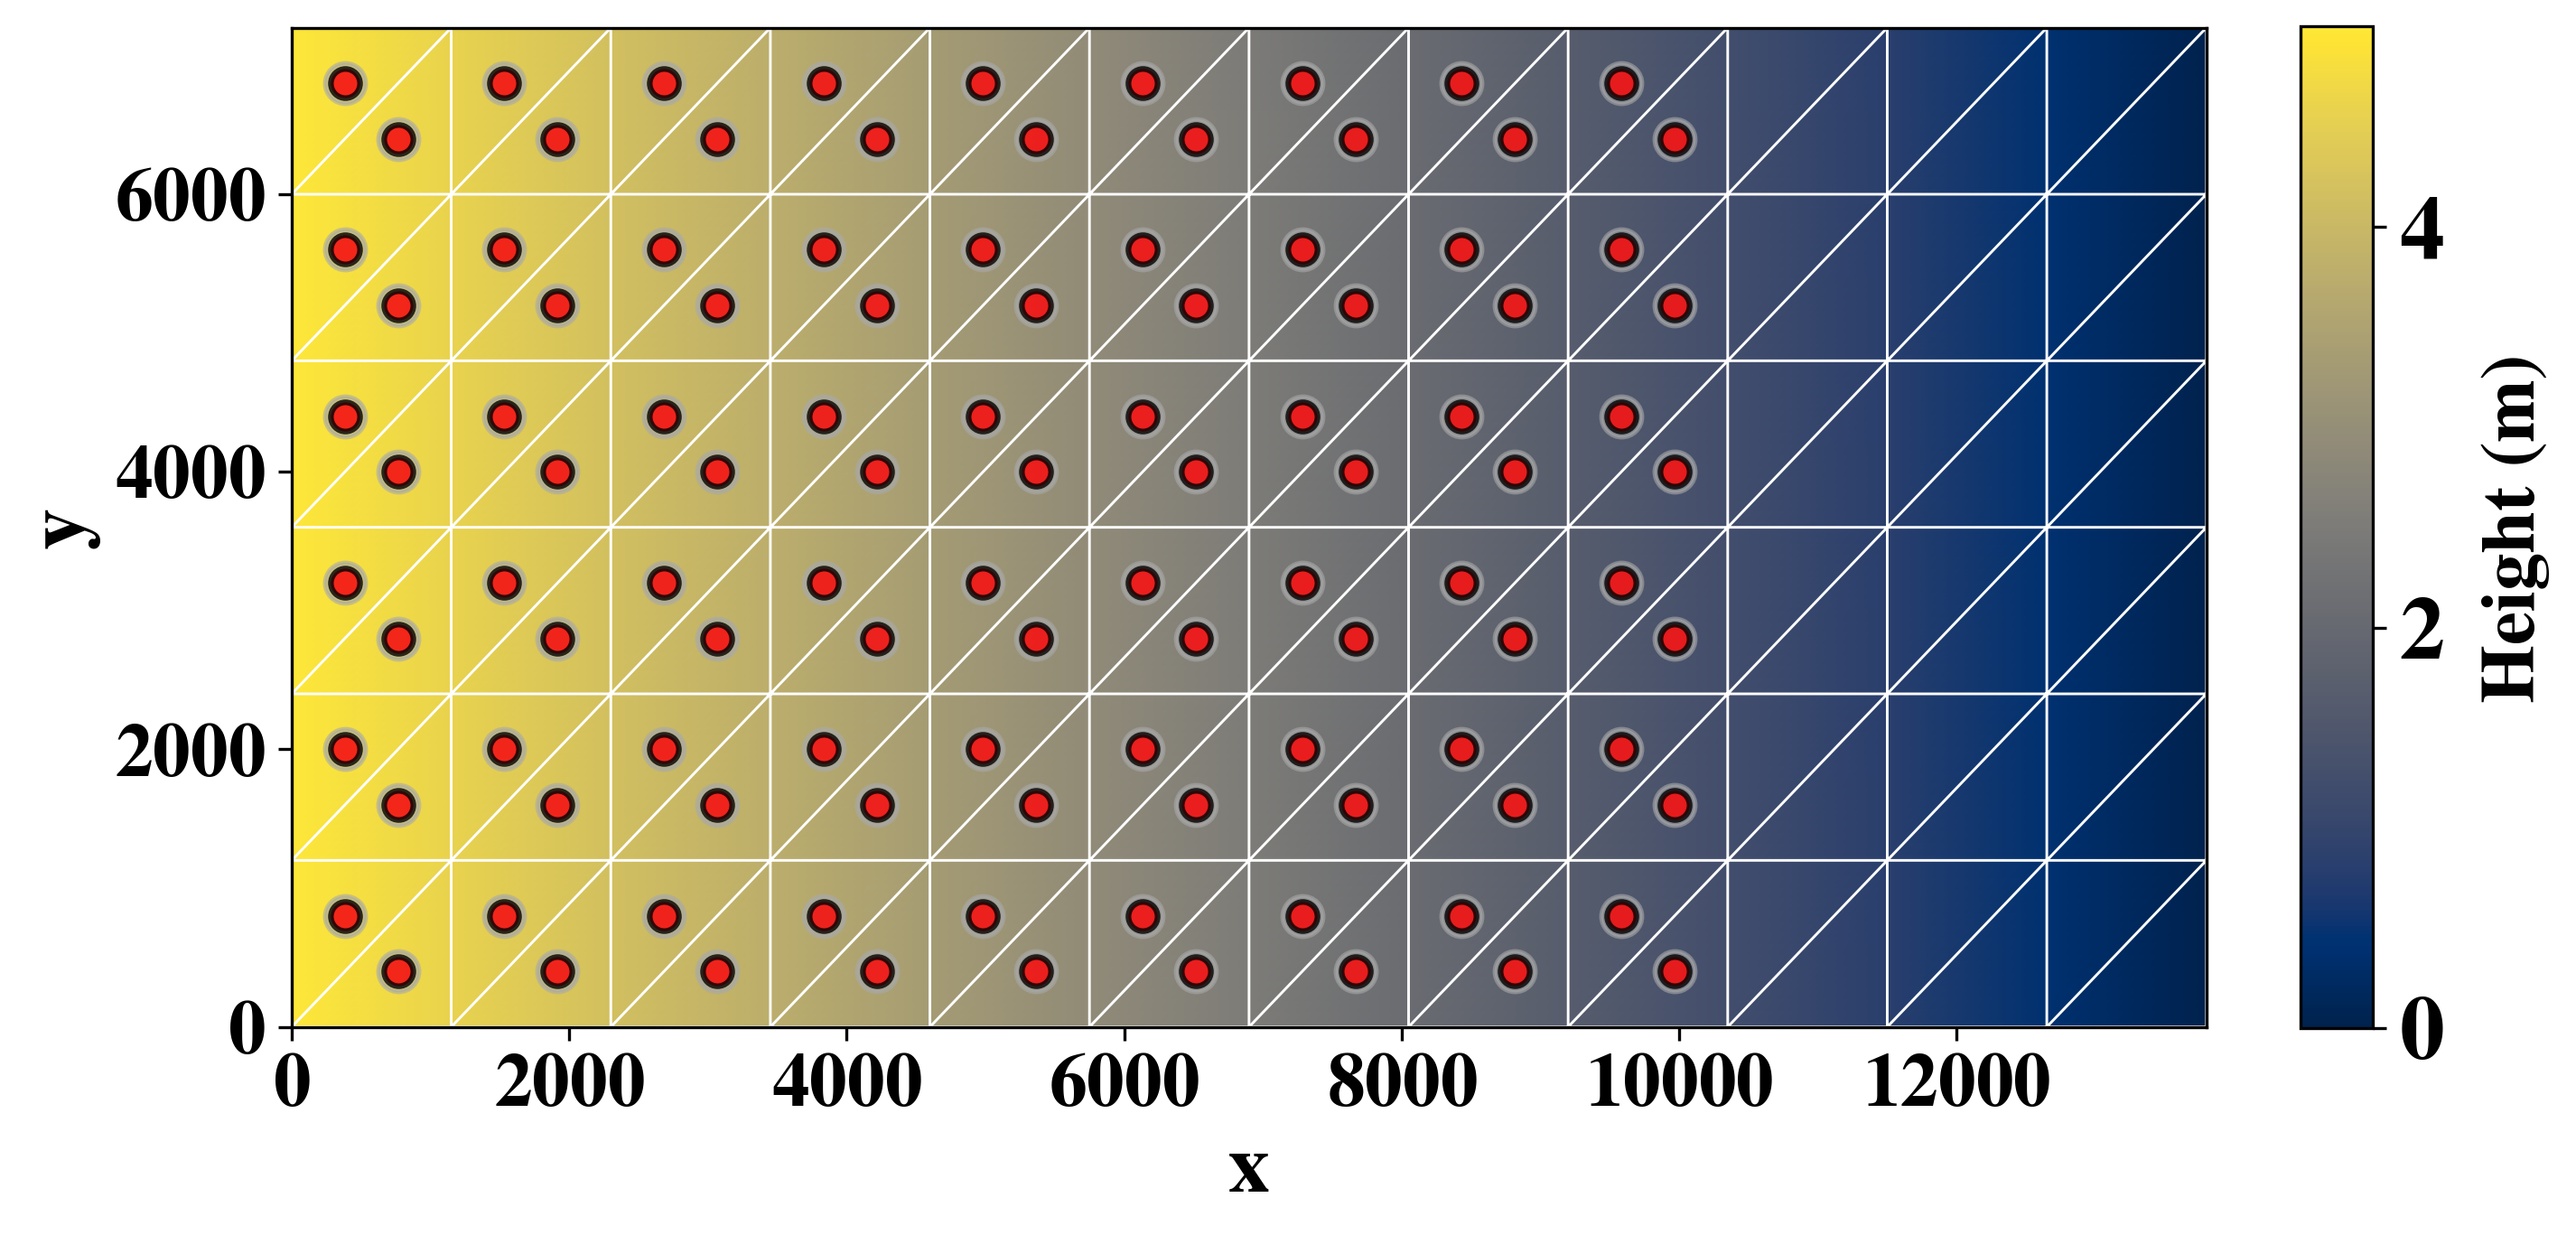

In [ ]:
# Use drop shadow
plot_mixed_function(prob.mesh,
                    prob.V,
                    true_solver.saved_states[0],
                    stations=result['stations'],
                    station_style='halo',
                    save_path='true_sloped_beach_plot.png')

In [ ]:
one_day = int(true_signal.shape[0] / 7)
plot_triplets = []

for day in range(1, 7):

    true = true_signal[day * one_day, :]
    bayes_estimate = bayes_analysis[day * one_day, :]
    dci_estimate = dci_analysis[day * one_day, :]
    dci_wme_estimate = dci_wme_analysis[day * one_day, :]
    bayes_diff = true - bayes_estimate
    dci_diff = true - dci_estimate
    dci_wme_diff = true - dci_wme_estimate
    plot_triplets.append((bayes_diff, dci_diff, dci_wme_diff))
    
    
# Add the final day using (7 * one_day - 1)
true = true_signal[(7 * one_day) - 1, :]
bayes_estimate = bayes_analysis[(7 * one_day) - 1, :]
dci_estimate = dci_analysis[(7 * one_day) - 1, :]
dci_wme_estimate = dci_wme_analysis[(7 * one_day) - 1, :]
bayes_diff = true - bayes_estimate
dci_diff = true - dci_estimate
dci_wme_diff = true - dci_wme_estimate
plot_triplets.append((bayes_diff, dci_diff, dci_wme_diff))

In [ ]:

def calculate_daily_differences(true_signal, bayes_analysis, dci_analysis, dci_wme_analysis, num_days=7):
    """
    Calculate differences between true signal and estimates for each day (explicit version).
    """
    time_steps_per_day = true_signal.shape[0] // num_days
    plot_triplets = []
    
    # Process days 1 through (num_days-1)
    for day in range(1, num_days):
        time_index = day * time_steps_per_day
        
        true_val = true_signal[time_index, :]
        bayes_est = bayes_analysis[time_index, :]
        dci_est = dci_analysis[time_index, :]
        dci_wme_est = dci_wme_analysis[time_index, :]
        
        differences = (
            true_val - bayes_est,    # bayes_diff
            true_val - dci_est,      # dci_diff
            true_val - dci_wme_est   # dci_wme_diff
        )
        plot_triplets.append(differences)
    
    # Handle the final day (use last time step)
    final_index = true_signal.shape[0] - 1
    true_val = true_signal[final_index, :]
    bayes_est = bayes_analysis[final_index, :]
    dci_est = dci_analysis[final_index, :]
    dci_wme_est = dci_wme_analysis[final_index, :]
    
    final_differences = (
        true_val - bayes_est,
        true_val - dci_est,
        true_val - dci_wme_est
    )
    plot_triplets.append(final_differences)
    
    return plot_triplets


def calculate_daily_comparison(true_signal, analysis_result, num_days=7):
    """
    Calculate true values, estimates, and differences for each day (explicit version).
    """
    time_steps_per_day = true_signal.shape[0] // num_days
    plot_triplets = []
    
    # Process days 1 through (num_days-1)
    for day in range(1, num_days):
        time_index = day * time_steps_per_day
        
        true_val = true_signal[time_index, :]
        estimate = analysis_result[time_index, :]
        diff = true_val - estimate
        
        plot_triplets.append((true_val, estimate, diff))
    
    # Handle the final day (use last time step)
    final_index = true_signal.shape[0] - 1
    true_val = true_signal[final_index, :]
    estimate = analysis_result[final_index, :]
    diff = true_val - estimate
    
    plot_triplets.append((true_val, estimate, diff))
    
    return plot_triplets


In [ ]:
plot_triplets_1 = calculate_daily_differences(true_signal, bayes_analysis, dci_analysis, dci_wme_analysis)

In [ ]:
plot_comparison1(prob.mesh,
                prob.V,
                plot_triplets_1,
                component=0,
                titles=None,
                stations=None,
                cmap='cividis',
                diff_cmap='hot_r',
                selected_days=[1,2,3,4,5,6,7],
                save_path='sloped_beach_comparison.png',
                dpi=300,
                format='png',
                show=True)

In [ ]:
plot_triplets_2 = calculate_daily_comparison(true_signal, dci_wme_analysis)

In [ ]:
one_day = int(true_signal.shape[0] / 7)
plot_triplets = []

for day in range(1, 7):
    true = true_signal[day * one_day, :]
    estimate = bayes_analysis[day * one_day, :]
    diff = true - estimate
    plot_triplets.append((true, estimate, diff))

# Add the final day using (7 * one_day - 1)
true = true_signal[(7 * one_day) - 1, :]
estimate = bayes_analysis[(7 * one_day) - 1, :]
diff = true - estimate
plot_triplets.append((true, estimate, diff))


plot_comparison2(prob.mesh,
                prob.V,
                plot_triplets_2,
                component=0,
                titles=None,
                stations=None,
                cmap='hot_r',
                diff_cmap='Spectral',
                save_path=None,
                dpi=300,
                format='png',
                show=True)